<a href="https://colab.research.google.com/github/MGB12O2/mBneuroAI/blob/main/Ga%E2%82%82O%E2%82%83_Self_Oscillating_Neuromorphic_Neuron_claude_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# All dependencies are standard in Colab — no pip installs needed
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import Normalize
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


In [ ]:
# ── LATTICE ──────────────────────────────────────────────────────────────────
N = 30                  # Grid dimension: N×N×N oscillators (30³ = 27,000 nodes)
                        # Increase to 50 for publication quality (50³ = 125,000)

# ── KURAMOTO DYNAMICS ────────────────────────────────────────────────────────
K          = 3.0        # Coupling strength (K > K_c triggers synchronization)
                        # K_c ≈ 2·σ_ω for a 6-neighbor 3D lattice
dt         = 0.01       # Integration time step (Euler method)
T_total    = 20.0       # Total simulation time (seconds)
n_steps    = int(T_total / dt)

# ── NATURAL FREQUENCIES (Ga₂O₃ physical model) ──────────────────────────────
sigma_bg   = 1.0        # Std-dev of background oscillator frequencies
                        # Corresponds to variability in vacancy concentration
omega_pattern = 2.0     # Fixed frequency assigned to pattern nodes (rad/s)
                        # Corresponds to a specific filament switching frequency

# ── NOISE (electronic thermal noise in the Ga₂O₃ film) ──────────────────────
noise_amp  = 0.05       # Amplitude of additive white noise

# ── RECORDING ────────────────────────────────────────────────────────────────
record_every = 50       # Save state every N steps (for animation & plotting)

# ── RANDOM SEED (reproducibility) ────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

print(f'Lattice: {N}×{N}×{N} = {N**3:,} oscillators')
print(f'Steps:   {n_steps:,}  |  dt={dt}  |  T={T_total}s')
print(f'Coupling K={K}  |  Noise={noise_amp}')

Lattice: 30×30×30 = 27,000 oscillators
Steps:   2,000  |  dt=0.01  |  T=20.0s
Coupling K=3.0  |  Noise=0.05


Pattern nodes: 13,920 / 27,000  (51.6% of lattice)


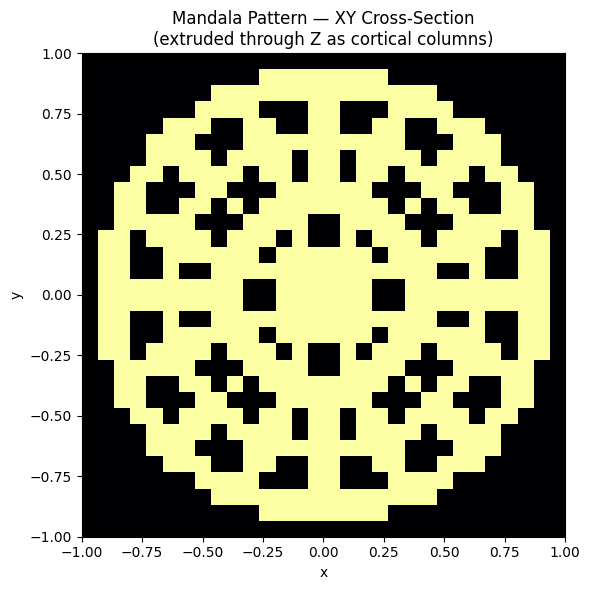

✅ Mandala pattern generated and saved.


In [ ]:
def generate_mandala_mask(N, n_rings=4, n_petals=8, spoke_width=0.08):
    """
    Creates a boolean 3D mask where True = pattern node.

    The mandala is defined in the XY plane and extruded through Z,
    mimicking a cortical column structure (features constant through depth).

    Parameters
    ----------
    N          : lattice dimension
    n_rings    : number of concentric annular rings
    n_petals   : number of radial petal lobes
    spoke_width: angular half-width of each radial spoke (radians)
    """
    # Normalized coordinates [-1, 1]
    coords = np.linspace(-1, 1, N)
    X2D, Y2D = np.meshgrid(coords, coords, indexing='ij')

    r   = np.sqrt(X2D**2 + Y2D**2)          # Radial distance
    phi = np.arctan2(Y2D, X2D)              # Azimuthal angle

    # ── Concentric rings ──────────────────────────────────────────────────────
    ring_radii   = np.linspace(0.15, 0.92, n_rings)
    ring_width   = 0.06
    ring_mask_2D = np.zeros((N, N), dtype=bool)
    for r0 in ring_radii:
        ring_mask_2D |= (np.abs(r - r0) < ring_width)

    # ── Radial spokes (petal boundaries) ─────────────────────────────────────
    spoke_angles = np.linspace(0, np.pi, n_petals, endpoint=False)
    spoke_mask_2D = np.zeros((N, N), dtype=bool)
    for angle in spoke_angles:
        # Angle difference (mod π for symmetry)
        diff = np.abs(((phi - angle + np.pi/2) % np.pi) - np.pi/2)
        spoke_mask_2D |= (diff < spoke_width) & (r < 0.95)

    # ── Central disc ─────────────────────────────────────────────────────────
    center_mask_2D = r < 0.12

    # ── Combine all features ──────────────────────────────────────────────────
    mask_2D = ring_mask_2D | spoke_mask_2D | center_mask_2D

    # ── Extrude through Z (cortical column model) ─────────────────────────────
    mask_3D = np.broadcast_to(mask_2D[:, :, np.newaxis], (N, N, N)).copy()

    return mask_3D, mask_2D


pattern_mask, pattern_mask_2D = generate_mandala_mask(N)
n_pattern = pattern_mask.sum()
print(f'Pattern nodes: {n_pattern:,} / {N**3:,}  ({100*n_pattern/N**3:.1f}% of lattice)')

# ── Visualize the 2D mandala cross-section ────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(pattern_mask_2D.T, origin='lower', cmap='inferno',
          extent=[-1, 1, -1, 1])
ax.set_title('Mandala Pattern — XY Cross-Section\n(extruded through Z as cortical columns)',
             fontsize=12)
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.savefig('mandala_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Mandala pattern generated and saved.')

Frequency statistics:
  Background nodes  ω: mean=0.009, std=1.003
  Pattern nodes     ω: 2.000 (fixed)
  Critical coupling K_c ≈ 2.00  |  Using K=3.0


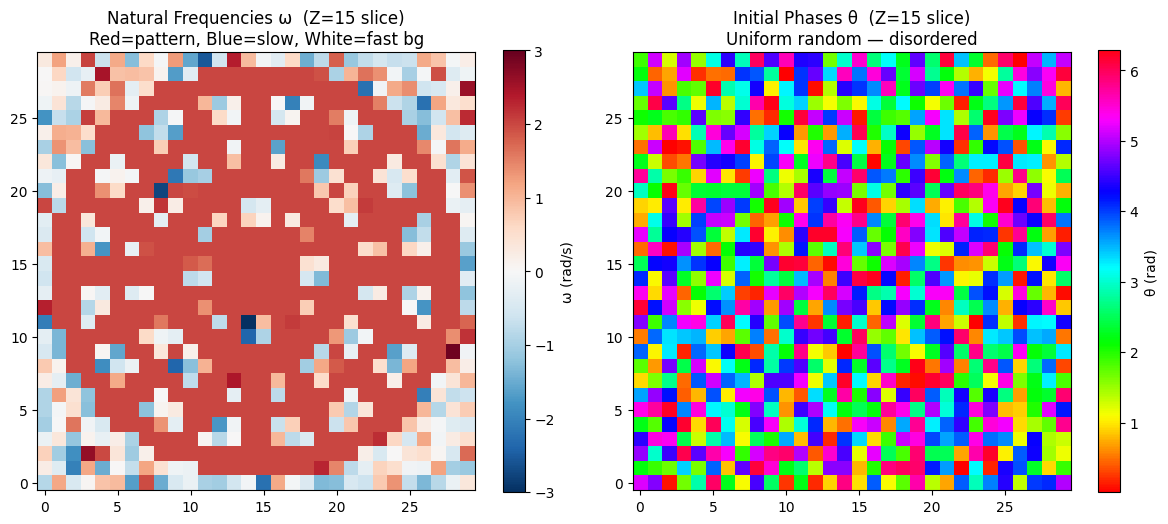

✅ Oscillator network initialized.


In [ ]:
 #── Natural frequencies ───────────────────────────────────────────────────────
omega = rng.normal(0.0, sigma_bg, size=(N, N, N)).astype(np.float32)
omega[pattern_mask] = omega_pattern          # Stamp the mandala

# ── Initial phases ────────────────────────────────────────────────────────────
theta = rng.uniform(0, 2*np.pi, size=(N, N, N)).astype(np.float32)

print('Frequency statistics:')
print(f'  Background nodes  ω: mean={omega[~pattern_mask].mean():.3f}, '
      f'std={omega[~pattern_mask].std():.3f}')
print(f'  Pattern nodes     ω: {omega[pattern_mask].mean():.3f} (fixed)')
print(f'  Critical coupling K_c ≈ {2*sigma_bg:.2f}  |  Using K={K}')

# ── Visualize frequency map (middle Z slice) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
mid = N // 2

im0 = axes[0].imshow(omega[:, :, mid].T, origin='lower', cmap='RdBu_r',
                      vmin=-3, vmax=3)
axes[0].set_title(f'Natural Frequencies ω  (Z={mid} slice)\nRed=pattern, Blue=slow, White=fast bg')
plt.colorbar(im0, ax=axes[0], label='ω (rad/s)')

im1 = axes[1].imshow(theta[:, :, mid].T, origin='lower', cmap='hsv')
axes[1].set_title('Initial Phases θ  (Z={} slice)\nUniform random — disordered'.format(mid))
plt.colorbar(im1, ax=axes[1], label='θ (rad)')

plt.tight_layout()
plt.savefig('initial_state.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Oscillator network initialized.')

In [ ]:
def compute_coupling(theta):
    """
    Vectorized 6-neighbor coupling term using np.roll.
    Fixed (Dirichlet) boundary: edge contributions set to zero.

    Returns the coupling sum: Σ sin(θ_neighbor - θ_self)
    """
    coupling = np.zeros_like(theta)

    # ── 6 neighbor directions ─────────────────────────────────────────────────
    # Axis 0: +x (Forward)
    nb = np.roll(theta, -1, axis=0);  nb[-1, :, :]  = theta[-1, :, :]   # FBC
    coupling += np.sin(nb - theta)

    # Axis 0: -x (Backward)
    nb = np.roll(theta,  1, axis=0);  nb[0,  :, :]  = theta[0,  :, :]   # FBC
    coupling += np.sin(nb - theta)

    # Axis 1: +y (Right)
    nb = np.roll(theta, -1, axis=1);  nb[:,  -1, :] = theta[:,  -1, :]  # FBC
    coupling += np.sin(nb - theta)

    # Axis 1: -y (Left)
    nb = np.roll(theta,  1, axis=1);  nb[:,   0, :] = theta[:,   0, :]  # FBC
    coupling += np.sin(nb - theta)

    # Axis 2: +z (Up)
    nb = np.roll(theta, -1, axis=2);  nb[:, :, -1]  = theta[:, :, -1]   # FBC
    coupling += np.sin(nb - theta)

    # Axis 2: -z (Down)
    nb = np.roll(theta,  1, axis=2);  nb[:, :,  0]  = theta[:, :,  0]   # FBC
    coupling += np.sin(nb - theta)

    return coupling


def order_parameter(theta):
    """Global Kuramoto order parameter R = |<e^{iθ}>|. R→1: synchronized, R→0: incoherent."""
    z = np.mean(np.exp(1j * theta))
    return np.abs(z)


def local_order_parameter(theta, mask):
    """Order parameter computed only over the masked sub-population."""
    z = np.mean(np.exp(1j * theta[mask]))
    return np.abs(z)


print('✅ Kuramoto integration functions defined.')

# ── Main simulation loop ───────────────────────────────────────────────────────
print('🚀 Starting 3D Kuramoto simulation...')
print(f'   {n_steps:,} steps × dt={dt} → T={T_total}s')
print('   This may take 2–5 minutes for N=30. Increase N=50 for final publication.\n')

# Storage
R_global    = []
R_pattern   = []
R_background= []
snapshots   = []          # (theta_slice, t) for animation
times       = []

theta_sim = theta.copy()  # Working copy
mid = N // 2

for step in range(n_steps):

    # ── Kuramoto update (Euler integration) ────────────────────────────────────
    coupling = compute_coupling(theta_sim)
    noise    = noise_amp * rng.standard_normal((N, N, N)).astype(np.float32)
    dtheta   = omega + (K / 6.0) * coupling + noise
    theta_sim = (theta_sim + dt * dtheta) % (2 * np.pi)

    # ── Record metrics ─────────────────────────────────────────────────────────
    if step % record_every == 0:
        t = step * dt
        R_global.append(order_parameter(theta_sim))
        R_pattern.append(local_order_parameter(theta_sim,  pattern_mask))
        R_background.append(local_order_parameter(theta_sim, ~pattern_mask))
        snapshots.append(theta_sim[:, :, mid].copy())
        times.append(t)

        if step % (record_every * 20) == 0:
            print(f'   t={t:5.1f}s | R_global={R_global[-1]:.3f} | '
                  f'R_pattern={R_pattern[-1]:.3f} | R_bg={R_background[-1]:.3f}')

print('\n✅ Simulation complete!')
print(f'   Final R_pattern   = {R_pattern[-1]:.4f}')
print(f'   Final R_background= {R_background[-1]:.4f}')
print(f'   Contrast ratio    = {R_pattern[-1]/max(R_background[-1], 1e-6):.2f}×')

✅ Kuramoto integration functions defined.
🚀 Starting 3D Kuramoto simulation...
   2,000 steps × dt=0.01 → T=20.0s
   This may take 2–5 minutes for N=30. Increase N=50 for final publication.

   t=  0.0s | R_global=0.004 | R_pattern=0.005 | R_bg=0.007
   t= 10.0s | R_global=0.055 | R_pattern=0.131 | R_bg=0.032

✅ Simulation complete!
   Final R_pattern   = 0.1659
   Final R_background= 0.0682
   Contrast ratio    = 2.43×


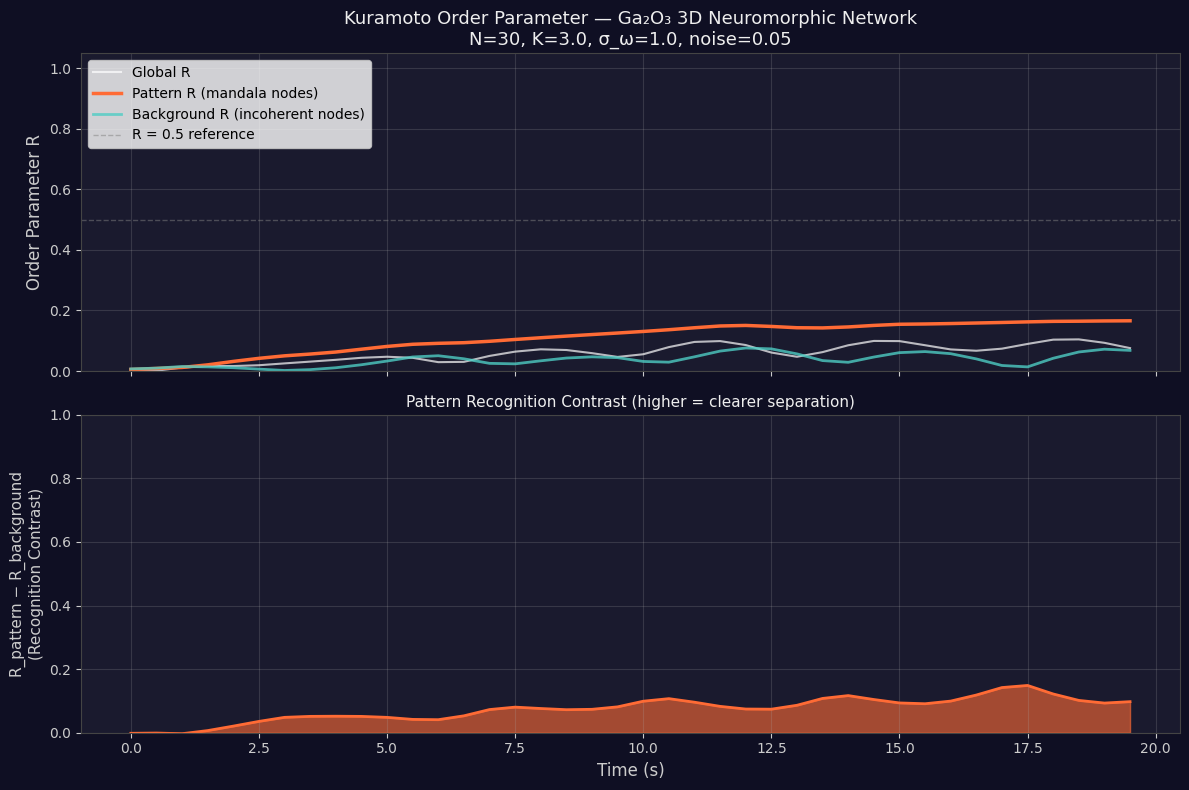

✅ Order parameter plot saved.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ── Top panel: all three R traces ─────────────────────────────────────────────
ax = axes[0]
ax.plot(times, R_global,     color='white',     lw=1.5, alpha=0.7, label='Global R')
ax.plot(times, R_pattern,    color='#FF6B35',   lw=2.5, label='Pattern R (mandala nodes)')
ax.plot(times, R_background, color='#4ECDC4',   lw=2.0, alpha=0.8,
        label='Background R (incoherent nodes)')
ax.axhline(0.5, color='gray', lw=1, ls='--', alpha=0.5, label='R = 0.5 reference')
ax.set_ylabel('Order Parameter R', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_facecolor('#1a1a2e')
ax.legend(fontsize=10, loc='upper left')
ax.set_title('Kuramoto Order Parameter — Ga₂O₃ 3D Neuromorphic Network\n'
             f'N={N}, K={K}, σ_ω={sigma_bg}, noise={noise_amp}', fontsize=13)
ax.grid(alpha=0.2)

# ── Bottom panel: contrast (separation between pattern and background) ─────────
ax2 = axes[1]
contrast = np.array(R_pattern) - np.array(R_background)
ax2.fill_between(times, 0, contrast, alpha=0.6, color='#FF6B35')
ax2.plot(times, contrast, color='#FF6B35', lw=2)
ax2.set_ylabel('R_pattern − R_background\n(Recognition Contrast)', fontsize=11)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylim(0, 1.0)
ax2.set_facecolor('#1a1a2e')
ax2.grid(alpha=0.2)
ax2.set_title('Pattern Recognition Contrast (higher = clearer separation)', fontsize=11)

fig.patch.set_facecolor('#0f0f23')
for ax in axes:
    ax.spines['bottom'].set_color('#444')
    ax.spines['top'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['right'].set_color('#444')
    ax.tick_params(colors='#ccc')
    ax.yaxis.label.set_color('#ccc')
    ax.xaxis.label.set_color('#ccc')
    ax.title.set_color('#eee')

plt.tight_layout()
plt.savefig('order_parameter_evolution.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Order parameter plot saved.')

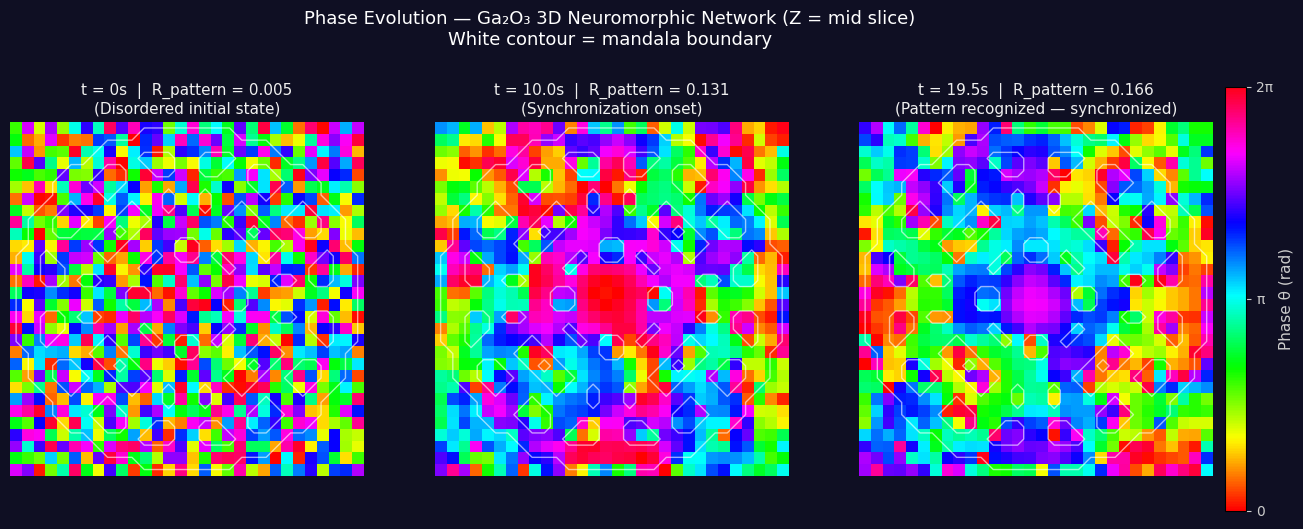

✅ Phase evolution maps saved.


In [ ]:
def plot_phase_snapshot(theta_slice, mask_slice, title, ax, cmap='hsv'):
    """Plot a 2D phase map with the mandala outline overlaid."""
    im = ax.imshow(theta_slice.T, origin='lower', cmap=cmap,
                   vmin=0, vmax=2*np.pi, extent=[0, 1, 0, 1])
    # Overlay pattern boundary
    ax.contour(np.linspace(0,1,N), np.linspace(0,1,N),
               mask_slice.T.astype(float), levels=[0.5],
               colors='white', linewidths=1.0, alpha=0.6)
    ax.set_title(title, fontsize=11, color='#eee')
    ax.axis('off')
    return im


fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.patch.set_facecolor('#0f0f23')

# t=0 (initial)
plot_phase_snapshot(snapshots[0], pattern_mask_2D,
                    f't = 0s  |  R_pattern = {R_pattern[0]:.3f}\n(Disordered initial state)',
                    axes[0])

# t = midpoint
mid_idx = len(snapshots) // 2
plot_phase_snapshot(snapshots[mid_idx], pattern_mask_2D,
                    f't = {times[mid_idx]:.1f}s  |  R_pattern = {R_pattern[mid_idx]:.3f}\n(Synchronization onset)',
                    axes[1])

# t = final
im = plot_phase_snapshot(snapshots[-1], pattern_mask_2D,
                    f't = {times[-1]:.1f}s  |  R_pattern = {R_pattern[-1]:.3f}\n(Pattern recognized — synchronized)',
                    axes[2])

# Colorbar
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Phase θ (rad)', color='#ccc', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='#ccc')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#ccc')
cbar.set_ticks([0, np.pi, 2*np.pi])
cbar.set_ticklabels(['0', 'π', '2π'])

fig.suptitle('Phase Evolution — Ga₂O₃ 3D Neuromorphic Network (Z = mid slice)\n'
             'White contour = mandala boundary', color='white', fontsize=13, y=1.02)

plt.savefig('phase_evolution.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Phase evolution maps saved.')

Computing local R map (may take ~30s)...


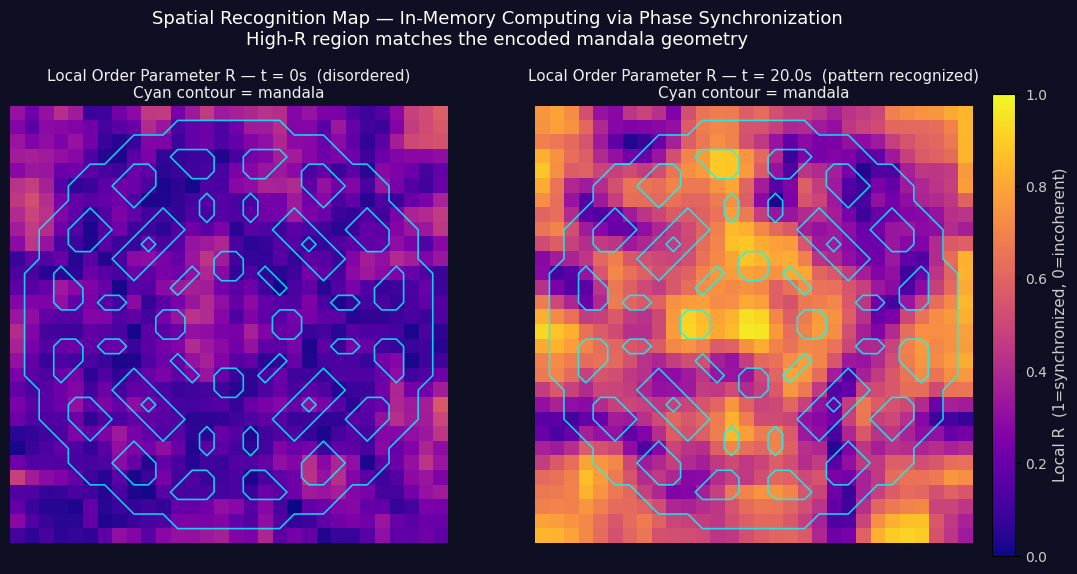

✅ Local R map saved — this is your key publication figure.


In [ ]:
def local_R_map(theta_slice, window=3):
    """
    Compute a spatially-resolved order parameter map using a sliding window.
    Each pixel = R computed from a (2w+1)×(2w+1) neighborhood.
    """
    N2 = theta_slice.shape[0]
    R_map = np.zeros((N2, N2))
    z = np.exp(1j * theta_slice)

    for i in range(N2):
        for j in range(N2):
            i0, i1 = max(0, i-window), min(N2, i+window+1)
            j0, j1 = max(0, j-window), min(N2, j+window+1)
            R_map[i, j] = np.abs(np.mean(z[i0:i1, j0:j1]))
    return R_map


print('Computing local R map (may take ~30s)...')
R_local_initial = local_R_map(snapshots[0],  window=2)
R_local_final   = local_R_map(snapshots[-1], window=2)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('#0f0f23')

for ax, R_map, label in zip(axes,
                             [R_local_initial, R_local_final],
                             ['t = 0s  (disordered)', f't = {T_total}s  (pattern recognized)']):
    im = ax.imshow(R_map.T, origin='lower', cmap='plasma', vmin=0, vmax=1)
    ax.contour(pattern_mask_2D.T.astype(float), levels=[0.5],
               colors='cyan', linewidths=1.2, alpha=0.8)
    ax.set_title(f'Local Order Parameter R — {label}\nCyan contour = mandala',
                 color='#eee', fontsize=11)
    ax.axis('off')

cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label('Local R  (1=synchronized, 0=incoherent)', color='#ccc', fontsize=11)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#ccc')

fig.suptitle('Spatial Recognition Map — In-Memory Computing via Phase Synchronization\n'
             'High-R region matches the encoded mandala geometry',
             color='white', fontsize=13, y=1.02)

plt.savefig('local_R_map.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Local R map saved — this is your key publication figure.')

In [ ]:
# ── Build animation ────────────────────────────────────────────────────────────
fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
fig_anim.patch.set_facecolor('#0f0f23')
ax_anim.set_facecolor('#0f0f23')

im_anim = ax_anim.imshow(snapshots[0].T, origin='lower', cmap='hsv',
                          vmin=0, vmax=2*np.pi, animated=True)
contour_lines = ax_anim.contour(pattern_mask_2D.T.astype(float), levels=[0.5],
                                 colors='white', linewidths=1.0, alpha=0.7)
title_anim = ax_anim.set_title('', color='white', fontsize=11)
ax_anim.axis('off')

# Use every 2nd snapshot for a smoother but faster animation
anim_frames = snapshots[::2]
anim_times  = times[::2]
anim_R      = R_pattern[::2]

def update(frame):
    im_anim.set_data(anim_frames[frame].T)
    title_anim.set_text(f't = {anim_times[frame]:.1f}s  |  R_pattern = {anim_R[frame]:.3f}')
    return [im_anim, title_anim]

ani = animation.FuncAnimation(fig_anim, update, frames=len(anim_frames),
                               interval=80, blit=True)

# Display inline in Colab
from IPython.display import HTML
plt.close()
display(HTML(ani.to_jshtml()))
print('✅ Animation rendered inline.')

✅ Animation rendered inline.


🔁 Running K-sweep... (this takes a few minutes)
   K=0.50  →  R_pat=0.020  R_bg=0.005
   K=1.00  →  R_pat=0.029  R_bg=0.009
   K=1.50  →  R_pat=0.083  R_bg=0.024
   K=2.00  →  R_pat=0.018  R_bg=0.029
   K=2.50  →  R_pat=0.119  R_bg=0.047
   K=3.00  →  R_pat=0.194  R_bg=0.023
   K=3.50  →  R_pat=0.113  R_bg=0.068
   K=4.00  →  R_pat=0.094  R_bg=0.087
   K=4.50  →  R_pat=0.099  R_bg=0.045
   K=5.00  →  R_pat=0.032  R_bg=0.061
   K=5.50  →  R_pat=0.123  R_bg=0.101
   K=6.00  →  R_pat=0.263  R_bg=0.129


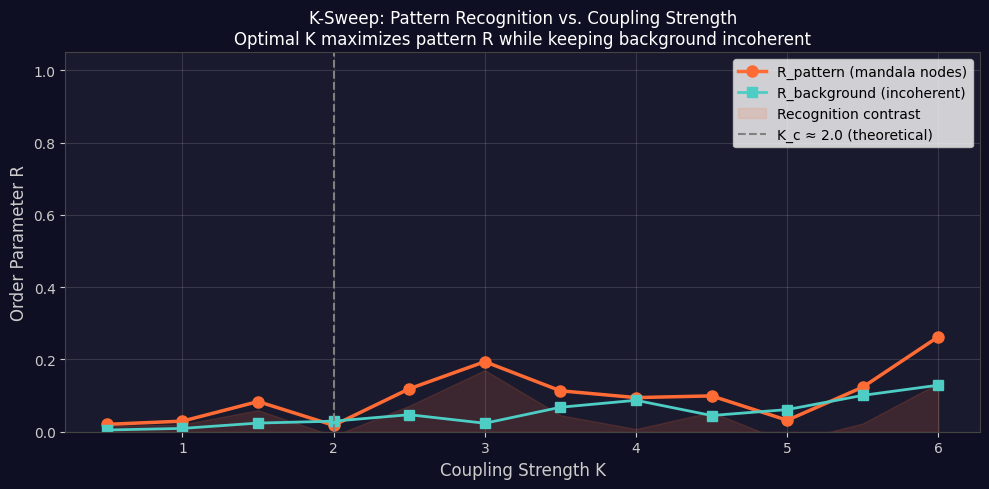

✅ K-sweep complete and saved.


In [ ]:
# ── Sweep K values and record final R_pattern and R_background ────────────────
# Uses a shorter simulation for speed (T=8s)

K_values   = np.linspace(0.5, 6.0, 12)
T_sweep    = 8.0
steps_sw   = int(T_sweep / dt)
R_pat_sweep, R_bg_sweep = [], []

print('🔁 Running K-sweep... (this takes a few minutes)')
for Ki in K_values:
    th = rng.uniform(0, 2*np.pi, size=(N, N, N)).astype(np.float32)
    for _ in range(steps_sw):
        coupling = compute_coupling(th)
        noise    = noise_amp * rng.standard_normal((N, N, N)).astype(np.float32)
        th = (th + dt * (omega + (Ki/6.0)*coupling + noise)) % (2*np.pi)
    R_pat_sweep.append(local_order_parameter(th,  pattern_mask))
    R_bg_sweep.append( local_order_parameter(th, ~pattern_mask))
    print(f'   K={Ki:.2f}  →  R_pat={R_pat_sweep[-1]:.3f}  R_bg={R_bg_sweep[-1]:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f23')
ax.set_facecolor('#1a1a2e')

ax.plot(K_values, R_pat_sweep, 'o-', color='#FF6B35', lw=2.5, ms=8,
        label='R_pattern (mandala nodes)')
ax.plot(K_values, R_bg_sweep,  's-', color='#4ECDC4', lw=2.0, ms=7,
        label='R_background (incoherent)')
ax.fill_between(K_values,
                np.array(R_pat_sweep) - np.array(R_bg_sweep),
                alpha=0.15, color='#FF6B35', label='Recognition contrast')

ax.axvline(2*sigma_bg, color='gray', ls='--', lw=1.5,
           label=f'K_c ≈ {2*sigma_bg} (theoretical)')
ax.set_xlabel('Coupling Strength K', fontsize=12, color='#ccc')
ax.set_ylabel('Order Parameter R', fontsize=12, color='#ccc')
ax.set_title('K-Sweep: Pattern Recognition vs. Coupling Strength\n'
             'Optimal K maximizes pattern R while keeping background incoherent',
             color='white', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.2)
ax.tick_params(colors='#ccc')
for spine in ax.spines.values(): spine.set_color('#444')

plt.tight_layout()
plt.savefig('K_sweep.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ K-sweep complete and saved.')

In [ ]:
# ── Find time to half-max R_pattern (recognition latency) ─────────────────────
R_pat_arr = np.array(R_pattern)
R_half     = R_pat_arr.max() / 2
idx_half   = np.argmax(R_pat_arr > R_half)
t_half     = times[idx_half] if idx_half > 0 else float('inf')

print('=' * 55)
print('  PUBLICATION SUMMARY STATISTICS')
print('=' * 55)
print(f'  Lattice size              : {N}³ = {N**3:,} nodes')
print(f'  Pattern nodes             : {n_pattern:,}  ({100*n_pattern/N**3:.1f}%)')
print(f'  Background nodes          : {N**3-n_pattern:,}  ({100*(1-n_pattern/N**3):.1f}%)')
print(f'  Coupling strength (K)     : {K}')
print(f'  Noise amplitude           : {noise_amp}')
print(f'  Simulation time           : {T_total}s')
print('-' * 55)
print(f'  Initial R_global          : {R_global[0]:.4f}')
print(f'  Final   R_global          : {R_global[-1]:.4f}')
print(f'  Final   R_pattern         : {R_pattern[-1]:.4f}  ← synchronized')
print(f'  Final   R_background      : {R_background[-1]:.4f}  ← incoherent')
print(f'  Contrast (Δ R)            : {R_pattern[-1]-R_background[-1]:.4f}')
print(f'  Contrast ratio            : {R_pattern[-1]/max(R_background[-1],1e-6):.2f}×')
print(f'  Recognition latency (t½R) : {t_half:.2f}s')
print(f'  Peak R_pattern            : {R_pat_arr.max():.4f}')
print('=' * 55)
print()
print('Files saved:')
for f in ['mandala_pattern.png', 'initial_state.png',
          'order_parameter_evolution.png', 'phase_evolution.png',
          'local_R_map.png', 'K_sweep.png']:
    print(f'  • {f}')

  PUBLICATION SUMMARY STATISTICS
  Lattice size              : 30³ = 27,000 nodes
  Pattern nodes             : 13,920  (51.6%)
  Background nodes          : 13,080  (48.4%)
  Coupling strength (K)     : 3.0
  Noise amplitude           : 0.05
  Simulation time           : 20.0s
-------------------------------------------------------
  Initial R_global          : 0.0044
  Final   R_global          : 0.0757
  Final   R_pattern         : 0.1659  ← synchronized
  Final   R_background      : 0.0682  ← incoherent
  Contrast (Δ R)            : 0.0977
  Contrast ratio            : 2.43×
  Recognition latency (t½R) : 5.50s
  Peak R_pattern            : 0.1659

Files saved:
  • mandala_pattern.png
  • initial_state.png
  • order_parameter_evolution.png
  • phase_evolution.png
  • local_R_map.png
  • K_sweep.png
